# Importing Libraries

In [50]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential

# Dataset


In [51]:
train_Dataset='/kaggle/input/datasets/amakii/asl-signs-preprocessed/DATASET/train'
test_Dataset='/kaggle/input/datasets/amakii/asl-signs-preprocessed/DATASET/test'

# Image Preprocessing

In [52]:
traindatagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

# Train & Test data generation

In [53]:
testdatagen=ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=False
)

In [54]:
train_data=traindatagen.flow_from_directory(
    train_Dataset,
    batch_size=32,
    class_mode='categorical',
    target_size=(128,128)
)

Found 12845 images belonging to 27 classes.


In [55]:
test_data=testdatagen.flow_from_directory(
    test_Dataset,
    batch_size=32,
    class_mode='categorical',
    target_size=(128,128)
)

Found 4268 images belonging to 27 classes.


In [56]:
print(test_data.class_indices)
print(train_data.class_indices)

{'0': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26}
{'0': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'O': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'U': 21, 'V': 22, 'W': 23, 'X': 24, 'Y': 25, 'Z': 26}


# Model

In [57]:
model = Sequential([

    Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation="relu",padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu",padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128,activation="relu"),
    Dropout(0.3),

    Dense(train_data.num_classes,activation="softmax")
])

In [58]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,520,411 (32.50 MB)

 Trainable params: 8,519,451 (32.50 MB)

 Non-trainable params: 960 (3.75 KB)

# compiling model

In [59]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [60]:
callbacks=[
    EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss',facror=0.3,patience=3,
                     min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_asl_eff.h5",monitor='val_accuracy',save_best_only=True, verbose=1)
]

# Training the model

In [61]:
history=model.fit(train_data,validation_data=test_data,epochs=30, callbacks=callbacks)

Epoch 1/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.4717 - loss: 1.8688
Epoch 1: val_accuracy improved from -inf to 0.48079, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 127s 299ms/step - accuracy: 0.4722 - loss: 1.8670 - val_accuracy: 0.4808 - val_loss: 1.7273 - learning_rate: 0.0010
Epoch 2/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8988 - loss: 0.3113
Epoch 2: val_accuracy did not improve from 0.48079
402/402 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.8988 - loss: 0.3112 - val_accuracy: 0.4496 - val_loss: 4.8141 - learning_rate: 0.0010
Epoch 3/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9347 - loss: 0.2073
Epoch 3: val_accuracy improved from 0.48079 to 0.63871, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.9347 - loss: 0.2072 - val_accuracy: 0.6387 - val_loss: 1.7263 - learning_rate: 0.0010
Epoch 4/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9670 - loss: 0.1093
Epoch 4: val_accuracy did not improve from 0.63871
402/402 ━━━━━━━━━━━━━━━━━━━━ 73s 182ms/step - accuracy: 0.9670 - loss: 0.1093 - val_accuracy: 0.5750 - val_loss: 18.1315 - learning_rate: 0.0010
Epoch 5/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9749 - loss: 0.0821
Epoch 5: val_accuracy improved from 0.63871 to 0.69096, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 72s 178ms/step - accuracy: 0.9749 - loss: 0.0821 - val_accuracy: 0.6910 - val_loss: 1.4416 - learning_rate: 0.0010
Epoch 6/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9769 - loss: 0.0739
Epoch 6: val_accuracy did not improve from 0.69096
402/402 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.9769 - loss: 0.0739 - val_accuracy: 0.0361 - val_loss: 145.4914 - learning_rate: 0.0010
Epoch 7/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9740 - loss: 0.0873
Epoch 7: val_accuracy improved from 0.69096 to 0.88355, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.9740 - loss: 0.0873 - val_accuracy: 0.8836 - val_loss: 0.4053 - learning_rate: 0.0010
Epoch 8/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9676 - loss: 0.1002
Epoch 8: val_accuracy improved from 0.88355 to 0.99485, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 70s 173ms/step - accuracy: 0.9676 - loss: 0.1002 - val_accuracy: 0.9948 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 9/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9768 - loss: 0.0665
Epoch 9: val_accuracy did not improve from 0.99485
402/402 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.9768 - loss: 0.0665 - val_accuracy: 0.7341 - val_loss: 1.4461 - learning_rate: 0.0010
Epoch 10/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9877 - loss: 0.0370
Epoch 10: val_accuracy did not improve from 0.99485
402/402 ━━━━━━━━━━━━━━━━━━━━ 70s 173ms/step - accuracy: 0.9877 - loss: 0.0370 - val_accuracy: 0.7903 - val_loss: 0.9424 - learning_rate: 0.0010
Epoch 11/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9867 - loss: 0.0433
Epoch 11: val_accuracy improved from 0.99485 to 0.99836, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 72s 178ms/step - accuracy: 0.9867 - loss: 0.0433 - val_accuracy: 0.9984 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 12/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9875 - loss: 0.0452
Epoch 12: val_accuracy did not improve from 0.99836
402/402 ━━━━━━━━━━━━━━━━━━━━ 71s 178ms/step - accuracy: 0.9875 - loss: 0.0452 - val_accuracy: 0.7545 - val_loss: 2.5652 - learning_rate: 0.0010
Epoch 13/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9846 - loss: 0.0520
Epoch 13: val_accuracy did not improve from 0.99836
402/402 ━━━━━━━━━━━━━━━━━━━━ 71s 176ms/step - accuracy: 0.9846 - loss: 0.0520 - val_accuracy: 0.8777 - val_loss: 0.6874 - learning_rate: 0.0010
Epoch 14/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9903 - loss: 0.0297
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 14: val_accuracy did not improve from 0.99836
402/402 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.9903 - l

402/402 ━━━━━━━━━━━━━━━━━━━━ 73s 181ms/step - accuracy: 0.9907 - loss: 0.0356 - val_accuracy: 0.9988 - val_loss: 0.0051 - learning_rate: 1.0000e-04
Epoch 16/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9949 - loss: 0.0183
Epoch 16: val_accuracy improved from 0.99883 to 0.99930, saving model to best_asl_eff.h5


402/402 ━━━━━━━━━━━━━━━━━━━━ 76s 188ms/step - accuracy: 0.9949 - loss: 0.0183 - val_accuracy: 0.9993 - val_loss: 0.0030 - learning_rate: 1.0000e-04
Epoch 17/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9949 - loss: 0.0161
Epoch 17: val_accuracy did not improve from 0.99930
402/402 ━━━━━━━━━━━━━━━━━━━━ 74s 185ms/step - accuracy: 0.9949 - loss: 0.0161 - val_accuracy: 0.9932 - val_loss: 0.0390 - learning_rate: 1.0000e-04
Epoch 18/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9958 - loss: 0.0131
Epoch 18: val_accuracy did not improve from 0.99930
402/402 ━━━━━━━━━━━━━━━━━━━━ 74s 183ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9991 - val_loss: 0.0049 - learning_rate: 1.0000e-04
Epoch 19/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9951 - loss: 0.0165
Epoch 19: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 19: val_accuracy did not improve from 0.99930
402/402 ━━━━━━━━━━━━━━━━━━━━ 73s 183ms/step - accuracy

# Saving the model

In [62]:
model.save("asl_skeleton_final.keras")

# Plotting the results

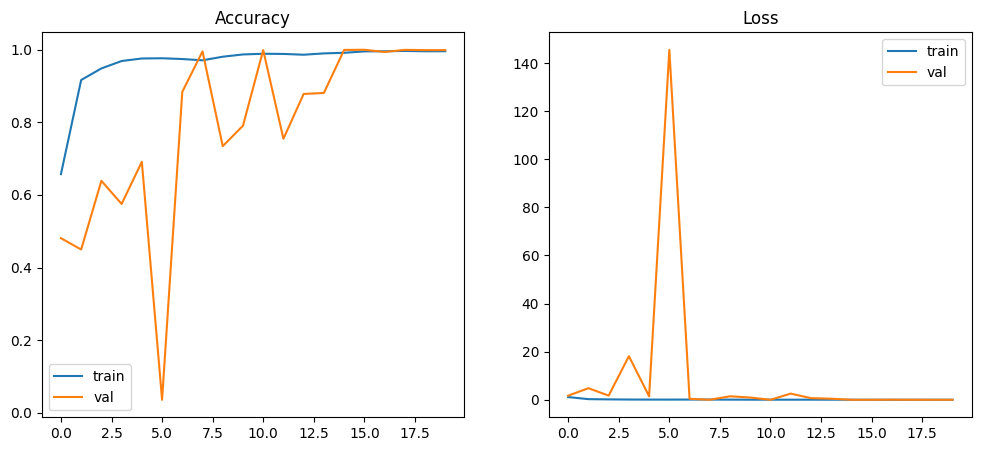

In [63]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["train","val"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["train","val"])

plt.show()